# 🎲 Student Performance Probability Analysis

## Day 21 – Understanding Probability Through Data

In this notebook, I explore the fundamentals of probability and conditional probability using a Student Performance dataset.

Probability helps quantify the likelihood of events occurring and forms the foundation of statistical inference and predictive analytics.

### Objectives

- Understand probability concepts
- Calculate event probabilities from data
- Explore frequency distributions
- Apply conditional probability
- Generate insights from observed outcomes

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [11]:
from IPython.display import HTML

HTML("""
<style>
.jp-Notebook {
    background: #1e1e1e;
}

.jp-Cell {
    border-radius: 12px;
    margin: 10px 0;
    padding: 10px;
}
</style>
""")

## Load Dataset

The dataset is loaded into a Pandas DataFrame for probability analysis.

In [2]:
data=pd.read_csv("/content/StudentPerformanceFactors.csv")

In [3]:
data.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

# Probability of Scoring at Least 70

Probability can be estimated directly from observed data.

In this example:

Event A = Student scores at least 70 marks.

Probability is calculated as:

Probability = Favorable Outcomes / Total Outcomes

In [ ]:
passed=(data["Exam_Score"] >=70).mean()

passed.round(2)

np.float64(0.25)

### Observation

The probability of scoring at least 70 marks is 0.25.

This means that approximately 25% of students in the dataset achieved a score of 70 or higher.


## Frequency Distribution of Exam Performance

A frequency distribution helps us understand how many students fall into each performance category.

### Observation

The majority of students scored between 60 and 70 marks, indicating that most students achieved average academic performance.

A smaller proportion of students scored between 70 and 80 marks, while only a few students achieved scores above 80.

This distribution suggests that exam scores are concentrated around the middle range rather than being evenly distributed across all score categories.

## Relative Frequency Distribution

Relative frequency represents the proportion of observations that fall within each category.

In probability analysis, relative frequency can be interpreted as the probability of randomly selecting an observation from a particular category.

### Observation

The majority of students (81%) scored between 60 and 70 marks.

Approximately 16% of students scored between 70 and 80 marks, while only 2% scored between 50 and 60 marks.

Very few students achieved scores above 80, indicating that exam performance is concentrated within the middle score ranges.

These proportions can be interpreted as probabilities when selecting a student at random from the dataset.

In [ ]:
data["Marks_Category"].value_counts(
    normalize=True
).sort_index().round(2)

,proportion
Marks_Category,
50-60,0.02
60-70,0.81
70-80,0.16
80-90,0.00
90-100,0.00


<Axes: xlabel='Marks_Category'>

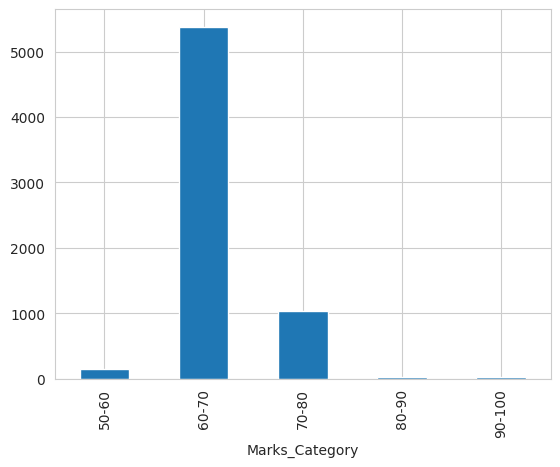

In [26]:
data["Marks_Category"] = pd.cut(
    data["Exam_Score"],
    bins=[50,60,70,80,90,100],
    labels=["50-60","60-70","70-80","80-90","90-100"]
)

data["Marks_Category"].value_counts().sort_index().plot(kind="bar")

### Observation

Most students scored between 60 and 70 marks.

A smaller proportion scored between 70 and 80 marks, while very few students achieved scores above 80.

This indicates that exam performance is concentrated within the middle score ranges.

In [13]:
high_attendance = data["Attendance"] >= 90

(
    data.loc[high_attendance, "Exam_Score"] >= 70
).mean().round(2)

np.float64(0.57)

### Observation

The probability of scoring at least 70 marks, given attendance of at least 90%, is 57%.

This suggests that students with higher attendance have a greater likelihood of achieving strong academic performance.

In [ ]:
range=np.max(data["Exam_Score"])-np.min(data["Exam_Score"])

print("Range=",range)

Range= 46


In [ ]:
p=np.percentile(data["Exam_Score"],90)
p

np.float64(72.0)

In [35]:
import plotly.express as px

fig = px.scatter(
    data,
    x="Attendance",
    y="Exam_Score",
    title="Attendance vs Exam Score",
    trendline="ols",  # regression line
    opacity=0.6
)

fig.update_layout(
    template="plotly_dark",
    width=1000,
    height=600,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(
    marker=dict(size=8)
)

fig.show()

In [39]:
from scipy import stats
print(stats.mode(data["Exam_Score"]))

ModeResult(mode=np.int64(68), count=np.int64(759))


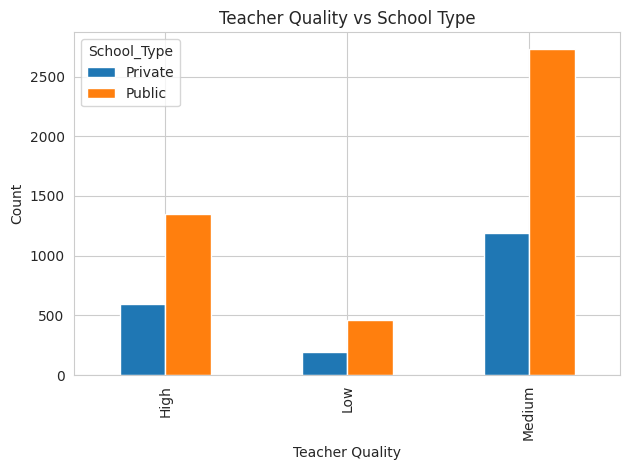

In [40]:
pd.crosstab(data["Teacher_Quality"],data["School_Type"]).plot(kind="bar")
plt.title("Teacher Quality vs School Type")
plt.xlabel("Teacher Quality")
plt.ylabel("Count")
plt.tight_layout()

<Axes: xlabel='Exam_Score', ylabel='Teacher_Quality'>

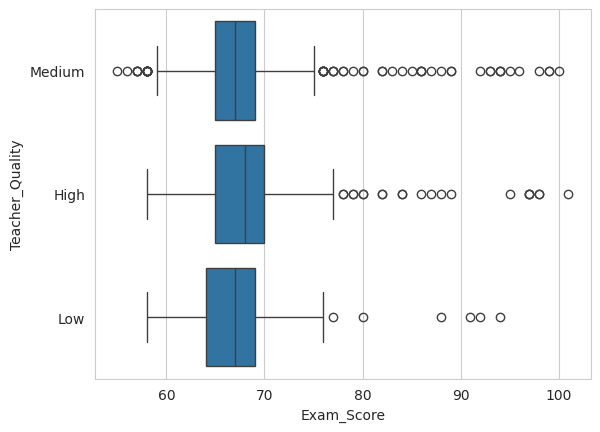

In [9]:
sns.boxplot(x="Exam_Score",y="Teacher_Quality",data=data)


### Observation

Students with higher teacher quality generally tend to achieve higher exam scores.

The spread of scores also varies across teacher quality levels.

## Key Findings

- Most students scored between 60 and 70 marks.
- Relative frequencies can be interpreted as probabilities.
- Approximately 25% of students scored 70 marks or higher.
- Students with attendance of at least 90% exhibited a higher probability of strong academic performance.
- Conditional probability provides more targeted insights than overall probability measures.

## Conclusion

This notebook applied probability, conditional probability, frequency distributions, relative frequencies, percentiles, and visualization techniques on a real-world student performance dataset.

The analysis showed that attendance, teacher quality, and score distributions can be effectively studied using statistical methods, providing practical insights into student performance.